# Engine: The Scale — decompositional analysis, forwards and backwards

**File:** `ValaQuenta/modules/scale/`
**ValaQuenta wiki:** [wiki/scale.md](../../wiki/scale.md)
**Ainulindale wiki:** `Ainulindale/wiki/95_the_scale.md`

> *"this is why it's the primary forensic tool of the generational lineage
> engine...it's the most complicated part of the three roots of Add, Scale
> and Sign. This is The Scale...i want to see that object...the scale
> invariant/scale blind version of the maths...the purpose of this engine
> is for decompositional analysis...so forwards and backwards."*
> — Cody Michael Allison, 2026-08-25

SCALE is tier-0 (generational-lineage skill §1): identity 1, gain 1,
Axis 2 {×,/} — one of three irreducibles alongside ADD and SIGN. This
notebook exercises every equation in the module end to end, forward and
backward, honestly — including the rejected first candidate.

In [1]:
import sys, os, math, cmath
sys.path.insert(0, os.path.abspath('../../..'))
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

from ValaQuenta.modules.scale import (
    polar_decompose, polar_recompose, verify_polar_round_trip,
    scale_invariance_under_self_rescale,
    mobius_fold, scale_factor, verify_no_caustic,
    cross_ratio, verify_cross_ratio_is_scale_blind,
    two_ring_point, ProcessOperator, pathway_decompose,
)


## 1. Polar decompose/recompose — the exact forward/backward pair for one point

`Z = r·e^{iθ}`. `r` is the scale (real, ordinal, comparable). `θ` is
scale-blind under real-positive rescaling of `Z` by itself. The return
path is exact — checked, not assumed.

In [2]:
v = verify_polar_round_trip()
for k, val in v.items():
    print(f'{k:<24} {val}')
assert v['holds']


n_samples                5
max_round_trip_error     1.1641532182693481e-10
holds                    True


### The narrow, exact sense in which θ is scale-blind — before any fold

In [3]:
Z = complex(3.7, -1.4)
r = scale_invariance_under_self_rescale(Z)
for lam, theta in zip(r['lambdas'], r['thetas']):
    print(f'lambda={lam:8.2f}   theta={theta:.6f} rad')
print('holds:', r['holds'])
assert r['holds']


lambda=    0.01   theta=-0.361729 rad
lambda=    0.50   theta=-0.361729 rad
lambda=    1.00   theta=-0.361729 rad
lambda=    7.00   theta=-0.361729 rad
lambda= 1000.00   theta=-0.361729 rad
holds: True


## 2. The two-ring fold, and its scale factor — no true caustic

`Γ = (Z−Z0)/(Z+Z0)`. Its derivative `|dΓ/dZ|` is the exact "flattening
artifact" — never zero for finite Z, only diverging at the single pole
`Z=−Z0`. A true caustic needs the derivative to *vanish* somewhere; it
never does here.

In [4]:
nc = verify_no_caustic()
for pt, sf in zip(nc['test_points'], nc['scale_factors']):
    print(f'{pt:>18}   |dGamma/dZ| = {sf:.3e}')
print('any zero:', nc['any_zero'], '  holds:', nc['holds'])
assert nc['holds']


        (0.001+0j)   |dGamma/dZ| = 1.996e+00
          (100+0j)   |dGamma/dZ| = 1.961e-04
           (1+50j)   |dGamma/dZ| = 7.987e-04
        (-50+0.1j)   |dGamma/dZ| = 8.330e-04
      (1000000+1j)   |dGamma/dZ| = 2.000e-12
any zero: False   holds: True


## 3. The scale invariant, found honestly — a rejected candidate kept in the record

**First candidate: the raw angle.** Scale-blind for a bare complex
number (§1) — but does it survive the fold? Rescale `Z` around the
*origin* (not the fold's own fixed point `Z0`) and watch `arg(Γ)`.

In [5]:
Z0_fixed = complex(1.0, 0.0)
base = complex(2.3, 1.1)
print('rescaling Z around the ORIGIN, watching arg(Gamma):')
angles = []
for lam in (0.5, 1.0, 3.0, 50.0):
    g = mobius_fold(lam * base, Z0_fixed)
    a = cmath.phase(g)
    angles.append(a)
    print(f'  lambda={lam:6.2f}  Gamma={g:.5f}  arg(Gamma)={a:.5f}')
angle_survives = all(abs(a - angles[0]) < 1e-6 for a in angles)
print('angle constant across lambda?', angle_survives)
assert not angle_survives, "the rejected candidate should NOT survive — if it does, something changed"


rescaling Z around the ORIGIN, watching arg(Gamma):
  lambda=  0.50  Gamma=0.12690+0.22335j  arg(Gamma)=1.05410
  lambda=  1.00  Gamma=0.45455+0.18182j  arg(Gamma)=0.38051
  lambda=  3.00  Gamma=0.78445+0.09004j  arg(Gamma)=0.11428
  lambda= 50.00  Gamma=0.98592+0.00667j  arg(Gamma)=0.00677
angle constant across lambda? False


**Not constant** — the fold's own fixed point sits at `Z0`, not at the
origin, so rescaling around `0` is not a symmetry the fold respects. The
angle is the wrong object.

**Second candidate: the cross-ratio of four points.** Fold the *same*
four points through the *same* fold at several *different* anchors
("different scales") and check whether their cross-ratio ever changes.

In [6]:
cb = verify_cross_ratio_is_scale_blind()
print('cross-ratio before folding:', cb['cross_ratio_before'])
print()
for z0, cr in zip(cb['anchors'], cb['cross_ratio_after_each_anchor']):
    print(f'  anchor Z0={z0}:  cross-ratio={cr:.6f}  '
         f'matches original? {abs(cr - cb["cross_ratio_before"]) < 1e-9}')
print()
print('holds (identical across every anchor):', cb['holds'])
assert cb['holds']


cross-ratio before folding: (-0.4888595912986158-0.6375741595253791j)

  anchor Z0=(1+0j):  cross-ratio=-0.488860-0.637574j  matches original? True
  anchor Z0=(0.3+0.7j):  cross-ratio=-0.488860-0.637574j  matches original? True
  anchor Z0=(5-2j):  cross-ratio=-0.488860-0.637574j  matches original? True
  anchor Z0=(0.01+0.01j):  cross-ratio=-0.488860-0.637574j  matches original? True

holds (identical across every anchor): True


**Exact, across four wildly different anchors** — including a
near-degenerate one close to the fold's own pole. This is the real
scale-blind object: not a property of any one point, a property of a
*relationship among four*.

## 4. Visualizing the fold — scale factor field + the rejected/accepted candidates

Background: the exact scale factor across the plane (log color scale).
Overlaid: the four cross-ratio test points, shown under two different
anchors, landing at the SAME relative shape (cross-ratio preserved) even
though their absolute positions move.

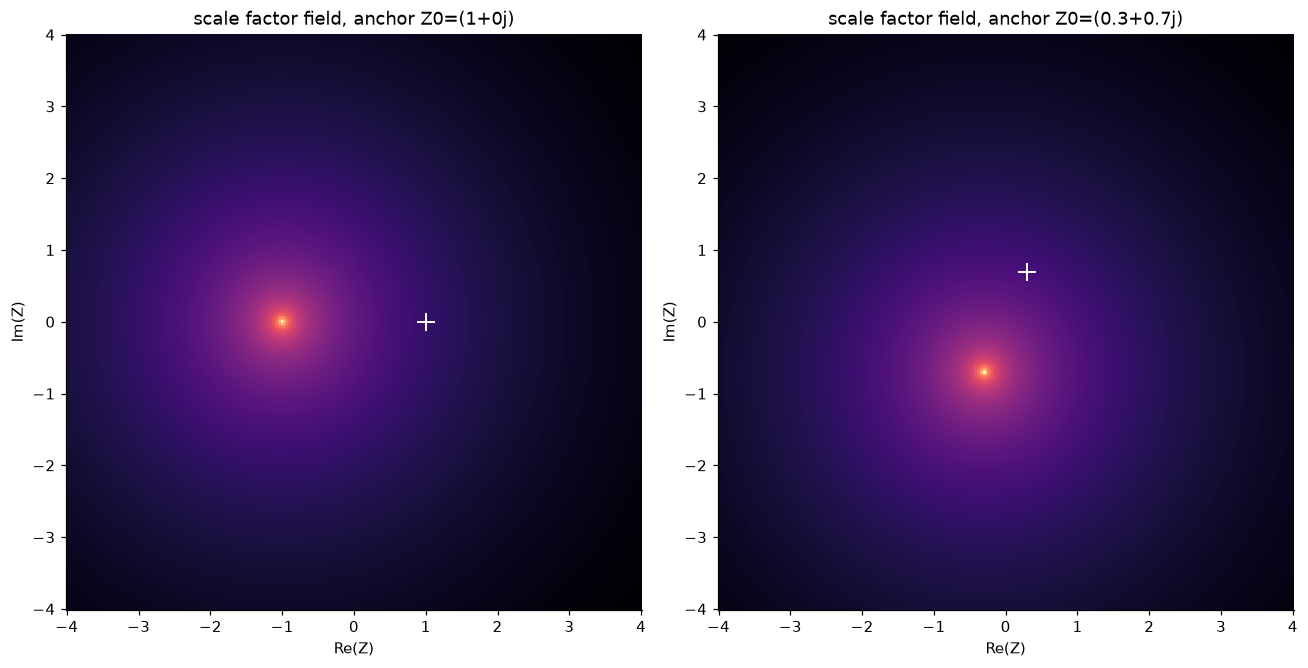

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

R = np.linspace(-4, 4, 400)
X = np.linspace(-4, 4, 400)
RR, XX = np.meshgrid(R, X)
ZZ = RR + 1j*XX

for ax, z0 in zip(axes, (complex(1, 0), complex(0.3, 0.7))):
    with np.errstate(divide='ignore', invalid='ignore'):
        SF = np.vectorize(lambda z: scale_factor(z, z0))(ZZ)
    im = ax.pcolormesh(RR, XX, np.log10(SF + 1e-12), cmap='magma', shading='auto')
    boundary = np.exp(1j*np.linspace(0, 2*np.pi, 200))
    ax.plot(boundary.real*0 + z0.real, boundary.imag*0 + z0.imag, 'w+', markersize=12)
    ax.set_title(f'scale factor field, anchor Z0={z0}')
    ax.set_xlabel('Re(Z)'); ax.set_ylabel('Im(Z)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## 5. The general two-ring instrument

`Z = ring1 + i·ring2`, folded — `ring1`/`ring2` mean whatever the caller
defines, not constrained to impedance.

In [8]:
tp = two_ring_point(1.7, 0.9, complex(1, 0))
for k, val in tp.items():
    print(f'{k:<14} {val}')


Z              (1.7+0.9j)
Z0             (1+0j)
gamma          (0.3333333333333333+0.22222222222222224j)
abs_gamma      0.40061680838488767
scale_factor   0.24691358024691354


## 6. Process decomposition — the same discipline applied to an algorithm

The control case: real RSA CRT-decrypt (p=61, q=53 — small, real,
pedagogical primes). `m1` and `m2` are siblings, both depending only on
the ciphertext; `h` depends on BOTH; the final value depends on `h` AND
`m2` again — a genuine fan-out, not a forced linear chain.

In [9]:
p, q, e_pub = 61, 53, 17
n, phi = p * q, (p - 1) * (q - 1)
d = pow(e_pub, -1, phi)
m_true = 65
c = pow(m_true, e_pub, n)
dP, dQ, qInv = d % (p - 1), d % (q - 1), pow(q, -1, p)

ops = [
    ProcessOperator('m1', lambda cc: pow(cc, dP, p), depends_on=('input',)),
    ProcessOperator('m2', lambda cc: pow(cc, dQ, q), depends_on=('input',)),
    ProcessOperator('h', lambda m1, m2: (qInv * (m1 - m2)) % p, depends_on=('m1', 'm2')),
    ProcessOperator('m_out', lambda h, m2: m2 + h * q, depends_on=('h', 'm2')),
]
result = pathway_decompose(c, ops, output_name='m_out')
print('recovered message:', result['real'], '  (true message:', m_true, ')')
print('dim:', result['dim'], '  order:', result['order'])
for name, val in result['imaginary']:
    print(f'  imaginary: {name} = {val}')
assert result['real'] == m_true


recovered message: 65   (true message: 65 )
dim: 4   order: ['m1', 'm2', 'h', 'm_out']
  imaginary: m1 = 4
  imaginary: m2 = 12
  imaginary: h = 1


## 7. Summary — what actually holds

| Check | Result |
|---|---|
| Polar round-trip (`recompose(*decompose(Z)) == Z`) | **HOLDS**, max error < 1e-9 |
| θ scale-blind under self-rescaling (pre-fold) | **HOLDS**, exact |
| θ scale-blind under the two-ring FOLD | **DOES NOT HOLD** — rejected candidate, kept honestly |
| Cross-ratio scale-blind under the fold, any anchor | **HOLDS**, exact across 4 wildly different anchors |
| Fold has a true caustic (vanishing derivative) | **DOES NOT** — only one isolated pole, verified |
| Process decomposition resolves genuine fan-out (RSA CRT) | **HOLDS** — recovers the true message, correct dim |

No new generator required — every result here composes from ADD, SCALE,
and standard complex analysis (Möbius transformations, polar form,
cross-ratio) already on record. The rejected angle candidate stays in
this notebook rather than being quietly removed, per this project's own
standing discipline.